In [4]:
import tensorflow as tf
import tensorflow.keras as K
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
from skimage.transform import resize
import scipy.io
import matplotlib.pyplot as plt
import itertools
import time
import shutil
import os

In [5]:
from GAN import GAN
cell_dir='dataset_A/cell_level_label'

In [6]:
X_train = np.load(f'{cell_dir}/X_train.npy')
X_test = np.load(f'{cell_dir}/X_test.npy')
y_train = np.load(f'{cell_dir}/y_train.npy')
y_test = np.load(f'{cell_dir}/y_test.npy')

X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
for i in range(X_train.shape[0]):
    X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
for i in range(X_test.shape[0]):
    X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

X_train_resized = 2 * X_train_resized - 1
X_test_resized = 2 * X_test_resized - 1


(1631, 32, 32, 3)


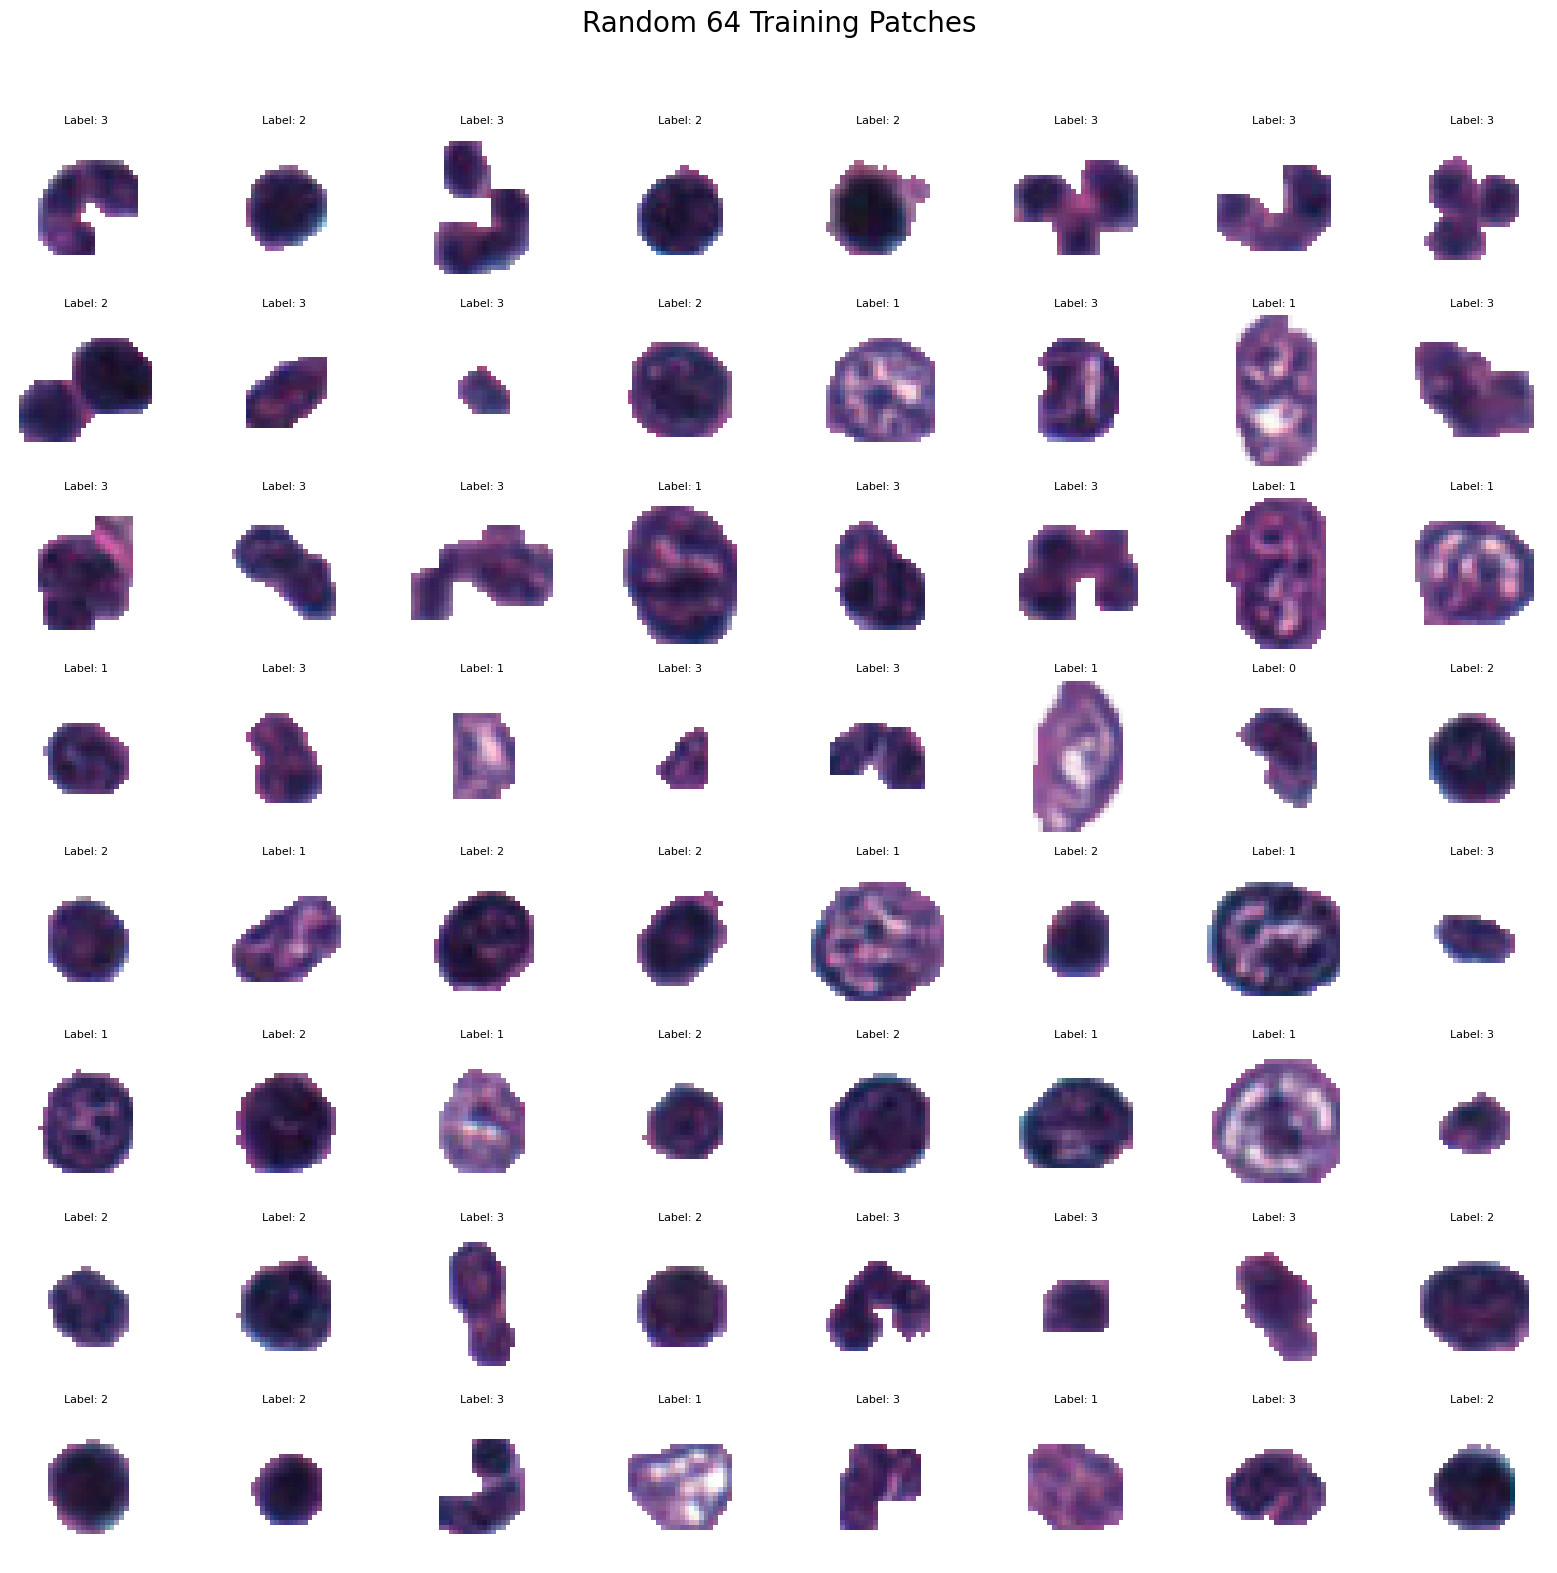

In [8]:
X_train_dis = (X_train_resized + 1) / 2.0
print(X_train_dis.shape)

n_plot = min(64, X_train_dis.shape[0]) 
random_indices = np.random.choice(X_train_dis.shape[0], n_plot, replace=False)
plt.figure(figsize=(16, 16)) 
for idx, random_idx in enumerate(random_indices):
    ax = plt.subplot(8, 8, idx + 1)
    ax.imshow(X_train_dis[random_idx])
    lbl = y_train[random_idx][0] if y_train.ndim > 1 else y_train[random_idx]
    ax.set_title(f"Label: {lbl}", fontsize=8)
    ax.axis('off')

plt.suptitle("Random 64 Training Patches", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [5]:
class GAN():
    def __init__(self):
        
        """
        -----------------------------------------------------------------------------------------------
        Define image shape for TMI data(32x32x3)
        -----------------------------------------------------------------------------------------------
        """ 
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        
        
        """
        -----------------------------------------------------------------------------------------------
        Define number of class
        -----------------------------------------------------------------------------------------------
        """ 
        self.latent_dim = 100
        self.num_classes = 4
        
        """
        -----------------------------------------------------------------------------------------------
         Define training history
        -----------------------------------------------------------------------------------------------
        """ 
        self.training_history = {
                'D_loss': [],
                'D_acc': [],
                'G_loss': [],
                'G_acc': [],
                }

        """
        -----------------------------------------------------------------------------------------------
         Build discriminator model
        -----------------------------------------------------------------------------------------------
        """ 
        self.discriminator = self.build_discriminator()
        
        """
        -----------------------------------------------------------------------------------------------
         Compile discriminator using Adam optimizer
         binary crossentropy is used to distinguish among real or fake samples
         categorical entropy is to distinguish among which real category is (nuclei or non-nuclei)
        -----------------------------------------------------------------------------------------------
        """ 
        optimizer =  K.optimizers.Adam(learning_rate=0.0002)
        self.discriminator.compile(
                loss=['binary_crossentropy', 'categorical_crossentropy'],
                optimizer=optimizer,
                metrics=['accuracy'])

        """
        -----------------------------------------------------------------------------------------------
         Build the generator
        -----------------------------------------------------------------------------------------------
        """ 
        self.generator = self.build_generator()

        """
        -----------------------------------------------------------------------------------------------
         The generator takes noise as input and generates imgs
        -----------------------------------------------------------------------------------------------
        """ 
        z = K.layers.Input(shape=(self.latent_dim,))
        img = self.generator(z)

        """
        -----------------------------------------------------------------------------------------------
         For the combined model only generator is trained
        -----------------------------------------------------------------------------------------------
        """ 
        self.discriminator.trainable = False

        """
        -----------------------------------------------------------------------------------------------
         The discriminator takes generated images as input and determines validity
        -----------------------------------------------------------------------------------------------
        """ 
        validity, _ = self.discriminator(img)

        """
        -----------------------------------------------------------------------------------------------
         The combined model (generator and discriminator) takes 
         noise as input => generates images => determines validity
        -----------------------------------------------------------------------------------------------
        """
        self.combined = K.Model(z, validity)
        self.combined.compile(loss='binary_crossentropy', optimizer=optimizer)
        


    def build_generator(self):
        
        """
        -----------------------------------------------------------------------------------------------
         Model creation for generator
        -----------------------------------------------------------------------------------------------
        """
        model = K.Sequential()
        
        """
        -----------------------------------------------------------------------------------------------
         Add layers
        -----------------------------------------------------------------------------------------------
        """ 
        model.add(K.layers.Dense(128 * 8 * 8, activation="relu", input_dim=100)) 
        model.add(K.layers.Dense(256, input_dim=self.latent_dim))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Dense(512))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Dense(1024))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Dense(np.prod(self.img_shape), activation='tanh'))
        model.add(K.layers.Reshape(self.img_shape))

        """
        -----------------------------------------------------------------------------------------------
         Generate noise and Image
        -----------------------------------------------------------------------------------------------
        """ 
        noise = K.layers.Input(shape=(self.latent_dim,))
        img = model(noise)
        
        """
        -----------------------------------------------------------------------------------------------
         Return Model
        -----------------------------------------------------------------------------------------------
        """ 
        return K.Model(noise, img)
    
    

    def build_discriminator(self):

        """
        -----------------------------------------------------------------------------------------------
         Model creation for discriminator
        -----------------------------------------------------------------------------------------------
        """ 
        model = K.Sequential()
        
        """
        -----------------------------------------------------------------------------------------------
        Add layers
        -----------------------------------------------------------------------------------------------
        """ 
        model.add(K.layers.Conv2D(32, kernel_size=3, strides=2, input_shape= self.img_shape, padding="same"))        
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Conv2D(64, kernel_size=3, strides=2, padding="same"))
        model.add(K.layers.ZeroPadding2D(padding=((0,1),(0,1))))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))        
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Conv2D(128, kernel_size=3, strides=2, padding="same"))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Conv2D(256, kernel_size=3, strides=1, padding="same"))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Flatten())     

        """
        -----------------------------------------------------------------------------------------------
         Gereate image and features
        -----------------------------------------------------------------------------------------------
        """ 
        img = K.layers.Input(shape=self.img_shape)
        features = model(img)
        
        """
        -----------------------------------------------------------------------------------------------
         valid indicates if the image is real or fake
        -----------------------------------------------------------------------------------------------
        """ 
        valid = K.layers.Dense(1, activation="sigmoid")(features)
        
        """
        -----------------------------------------------------------------------------------------------
         label indicates which type of image it is
        -----------------------------------------------------------------------------------------------
        """ 
        label = K.layers.Dense(self.num_classes+1, activation="softmax")(features)
        
        """
        -----------------------------------------------------------------------------------------------
         Return model
        -----------------------------------------------------------------------------------------------
        """ 
        return K.Model(img, [valid, label])
    
    

    def train(self, X_train, y_train, X_test, y_test, epochs, batch_size, save_interval):
        
        """
        -----------------------------------------------------------------------------------------------
         Delete directory if exist and create it
        -----------------------------------------------------------------------------------------------
        """ 
        shutil.rmtree('GAN_generators_output', ignore_errors=True)
        os.makedirs("GAN_generators_output")
       
        """
        -----------------------------------------------------------------------------------------------
         Adversarial ground truths
        -----------------------------------------------------------------------------------------------
        """
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        for epoch in range(epochs):

            """
            -----------------------------------------------------------------------------------------------
             Training the Discriminator
             Select a random batch of images
            -----------------------------------------------------------------------------------------------
            """ 
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            imgs = X_train[idx]

            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            
            """
            -----------------------------------------------------------------------------------------------
             Generate a batch of new images
            -----------------------------------------------------------------------------------------------
            """  
            gen_imgs = self.generator.predict(noise)
            
            """
            -----------------------------------------------------------------------------------------------
             Convert labels to categorical one-hot encoding
            -----------------------------------------------------------------------------------------------
            """ 
            labels = tf.keras.utils.to_categorical(y_train[idx], num_classes=self.num_classes+1)
            fake_labels = tf.keras.utils.to_categorical(np.full((batch_size, 1), 
                                                        self.num_classes),
                                                        num_classes=self.num_classes+1)
            """
            -----------------------------------------------------------------------------------------------
             Train the discriminator
            -----------------------------------------------------------------------------------------------
            """                   
            d_loss_real = self.discriminator.train_on_batch(imgs, [valid, labels])
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, [fake, fake_labels])
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            """
            -----------------------------------------------------------------------------------------------
             Train Generator
            -----------------------------------------------------------------------------------------------
            """
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            
            """
            -----------------------------------------------------------------------------------------------
             Train the generator (to have the discriminator label samples as valid)
            -----------------------------------------------------------------------------------------------
            """
            g_loss = self.combined.train_on_batch(noise, valid)
            
            """
            -----------------------------------------------------------------------------------------------
             Add history data
            -----------------------------------------------------------------------------------------------
            """ 
            self.training_history["D_loss"].append(d_loss[0]);
            self.training_history["D_acc"].append(100*d_loss[3]);
            self.training_history["G_loss"].append(g_loss);
            self.training_history["G_acc"].append(100*d_loss[4]);
            
            """
            -----------------------------------------------------------------------------------------------
             Print the result
            -----------------------------------------------------------------------------------------------
            """ 
            print ("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[3], g_loss))
            
            """
            -----------------------------------------------------------------------------------------------
             Evaluate test data for each epoch
            -----------------------------------------------------------------------------------------------
            """   
            self.evaluate_discriminator(X_test, y_test)

            """
            -----------------------------------------------------------------------------------------------
             If at save interval => save generated image samples
            -----------------------------------------------------------------------------------------------
            """ 
            if epoch % save_interval == 0:
                self.save_images(epoch)
                
                
                
    def evaluate_discriminator(self, X_test, y_test):
        valid = np.ones((y_test.shape[0], 1))
        
        """
        -----------------------------------------------------------------------------------------------
         Convert labels to categorical one-hot encoding
        -----------------------------------------------------------------------------------------------
        """ 
        labels = tf.keras.utils.to_categorical(y_test, num_classes=self.num_classes+1)
        
        """
        -----------------------------------------------------------------------------------------------
         Evaluating the trained Discriminator and print outputs
        -----------------------------------------------------------------------------------------------
        """ 
        scores = self.discriminator.evaluate(X_test, [valid, labels], verbose=0)

        print("Evaluating D [loss:  %.4f, bi-loss: %.4f, cat-loss: %.4f, bi-acc: %.2f%%, cat-acc: %.2f%%]\n" %
              (scores[0], scores[1], scores[2], scores[3]*100, scores[4]*100))

        return (scores[0], scores[3]*100)
    
    

    def save_images(self, epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)

        """
        -----------------------------------------------------------------------------------------------
         Rescale images from [-1..1] to [0..1] just to display purposes.
        -----------------------------------------------------------------------------------------------
        """ 
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt, :,:,0])
                axs[i,j].axis('off')
                cnt += 1
                
        """
        -----------------------------------------------------------------------------------------------
          Save generator image for each epoch
        -----------------------------------------------------------------------------------------------
        """ 
        fig.savefig("GAN_generators_output/gan_%d.png" % epoch)
        plt.close()
        
        
    
    def save_model(self):

        def save(model, model_name):
            
            """
            -----------------------------------------------------------------------------------------------
            Save weights
            -----------------------------------------------------------------------------------------------
            """
            model_path = "./CGAN_saved_models/%s.json" % model_name
            weights_path = "./CGAN_saved_models/%s_weights.hdf5" % model_name
            options = {"file_arch": model_path,
                        "file_weight": weights_path}
            json_string = model.to_json()
            open(options['file_arch'], 'w').write(json_string)
            model.save_weights(options['file_weight'])

        shutil.rmtree('CGAN_saved_models', ignore_errors=True)
        os.makedirs("CGAN_saved_models")
        
        """
        -----------------------------------------------------------------------------------------------
          Save models
        -----------------------------------------------------------------------------------------------
        """ 
        save(self.generator, "CGAN_gan_generator")
        save(self.discriminator, "CGAN_gan_discriminator")
        save(self.combined, "CGAN_gan_adversarial")


    def plot_training_history(self):
            
        """
        -----------------------------------------------------------------------------------------------
        Plot training history
        -----------------------------------------------------------------------------------------------
        """ 
        fig, axs = plt.subplots(1, 2, figsize=(15, 5))
        plt.title('Training History')
            
        """
        -----------------------------------------------------------------------------------------------
        Summarize history for G and D accuracy
        -----------------------------------------------------------------------------------------------
        """
        axs[0].plot(range(1, len(self.training_history['D_acc']) + 1), self.training_history['D_acc'])
        axs[0].plot(range(1, len(self.training_history['G_acc']) + 1), self.training_history['G_acc'])
        axs[0].set_title('D and G Accuracy')
        axs[0].set_ylabel('Accuracy')
        axs[0].set_xlabel('Epoch')
        
        # Corrected line to set xticks at regular intervals
        step_size = len(self.training_history['D_acc']) // 10  # Step size for ticks (spaced by roughly 1/10th of total length)
        axs[0].set_xticks(np.arange(1, len(self.training_history['D_acc']) + 1, step_size))  # Correct usage
        axs[0].set_yticks([n for n in range(0, 101, 10)])  # Y-axis ticks from 0 to 100 with step 10
        axs[0].legend(['Discriminator', 'Generator'], loc='best')
            
        """
        -----------------------------------------------------------------------------------------------
        Summarize history for G and D loss
        -----------------------------------------------------------------------------------------------
        """
        axs[1].plot(range(1, len(self.training_history['D_loss']) + 1), self.training_history['D_loss'])
        axs[1].plot(range(1, len(self.training_history['G_loss']) + 1), self.training_history['G_loss'])
        axs[1].set_title('D and G Loss')
        axs[1].set_ylabel('Loss')
        axs[1].set_xlabel('Epoch')
        
        # Corrected line to set xticks at regular intervals
        step_size = len(self.training_history['G_loss']) // 10  # Step size for ticks (spaced by roughly 1/10th of total length)
        axs[1].set_xticks(np.arange(1, len(self.training_history['G_loss']) + 1, step_size))  # Correct usage
        axs[1].legend(['Discriminator', 'Generator'], loc='best')
            
        """
        -----------------------------------------------------------------------------------------------
        Plot graphs
        -----------------------------------------------------------------------------------------------
        """
        plt.show()

        
    
        
    def predict(self, X_test, y_test):
        """
        -----------------------------------------------------------------------------------------------
        Generate predictions from the discriminator over the testing dataset
        -----------------------------------------------------------------------------------------------
        """
        # 1) raw discriminator output
        y_pred_out = self.discriminator.predict(X_test)

        # 2) discriminator.predict may return [real_fake, class_logits]
        if isinstance(y_pred_out, list):
            # assume second head is the classification logits
            class_logits = y_pred_out[1]
        else:
            class_logits = y_pred_out

        # 3) if the discriminator appended an extra "real/fake" class at the end,
        #    slice it off so we're left with num_classes columns
        if class_logits.shape[1] == self.num_classes + 1:
            class_probs = class_logits[:, : self.num_classes]
        else:
            class_probs = class_logits

        print(f"Shape of class_probs: {class_probs.shape}")  # should be (n_samples, num_classes)

        # 4) one-hot encode y_test for average_precision_score
        y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=self.num_classes)

        # 5) compute Average Precision (macro)
        avep = average_precision_score(y_test_oh, class_probs, average='macro')
        print(f"\nAveP: {avep * 100:.2f}%\n")

        # 6) derive hard labels for accuracy / classification_report
        y_pred_labels = np.argmax(class_probs, axis=1)

        # 7) overall accuracy
        acc = accuracy_score(y_test, y_pred_labels)
        print(f"Overall accuracy: {acc * 100:.2f}%\n")

        # 8) classification report
        unique_classes = np.unique(y_test)
        class_names = [f"Class {i}" for i in unique_classes]
        print(
            "Classification report:\n"
            + classification_report(
                y_test,
                y_pred_labels,
                target_names=class_names,
                zero_division=0,
            )
        )

        # 9) confusion matrix
        cm = confusion_matrix(y_test, y_pred_labels)
        self.plot_confusion_matrix(cm, class_names)


    def plot_confusion_matrix(self,cm, classes,
                            normalize=False,
                            title='Confusion matrix',
                            cmap=plt.cm.Blues):
        """
        -----------------------------------------------------------------------------------------------
        Prints and plots the confusion matrix
        -----------------------------------------------------------------------------------------------
        """
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        
        
def load_cell_dataset_npy(cell_dir):
    """
    -----------------------------------------------------------------------------------------------
     Load pre-cropped cell images from .npy files
    -----------------------------------------------------------------------------------------------
    """
    X_train = np.load(f'{cell_dir}/X_train.npy')
    X_test = np.load(f'{cell_dir}/X_test.npy')
    y_train = np.load(f'{cell_dir}/y_train.npy')
    y_test = np.load(f'{cell_dir}/y_test.npy')

    """
    -----------------------------------------------------------------------------------------------
     Resize images to 32x32 if needed
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
    for i in range(X_train.shape[0]):
        X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

    X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
    for i in range(X_test.shape[0]):
        X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

    """
    -----------------------------------------------------------------------------------------------
     Normalize images from [0..1] to [-1..1]
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = 2 * X_train_resized - 1
    X_test_resized = 2 * X_test_resized - 1

    return X_train_resized, y_train, X_test_resized, y_test


In [6]:
X_train, y_train, X_test, y_test = load_cell_dataset_npy('dataset_A/cell_level_label')
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
Model=K.Model
gan=GAN()

Unique labels in y_train: [0 1 2 3]
Unique labels in y_test: [0 1 2 3]


In [7]:
start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32, save_interval=10)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))
gan.save_model()

1/1 [==============================] - 0s 455ms/step
0 [D loss: 2.558142, acc.: 46.88%] [G loss: 0.676150]
Evaluating D [loss:  2.1151, bi-loss: 0.5763, cat-loss: 1.5388, bi-acc: 100.00%, cat-acc: 49.18%]

1/1 [==============================] - 0s 93ms/step
1 [D loss: 2.541446, acc.: 56.25%] [G loss: 0.650233]
Evaluating D [loss:  1.9927, bi-loss: 0.5005, cat-loss: 1.4922, bi-acc: 100.00%, cat-acc: 51.37%]

1/1 [==============================] - 0s 52ms/step
2 [D loss: 2.007777, acc.: 60.94%] [G loss: 0.667782]
Evaluating D [loss:  1.8495, bi-loss: 0.4171, cat-loss: 1.4324, bi-acc: 100.00%, cat-acc: 53.30%]

1/1 [==============================] - 0s 52ms/step
3 [D loss: 1.335872, acc.: 82.81%] [G loss: 0.679455]
Evaluating D [loss:  1.6842, bi-loss: 0.3278, cat-loss: 1.3564, bi-acc: 100.00%, cat-acc: 51.92%]

1/1 [==============================] - 0s 147ms/step
4 [D loss: 1.010112, acc.: 96.88%] [G loss: 0.714043]
Evaluating D [loss:  1.4997, bi-loss: 0.2411, cat-loss: 1.2586, bi-acc: 

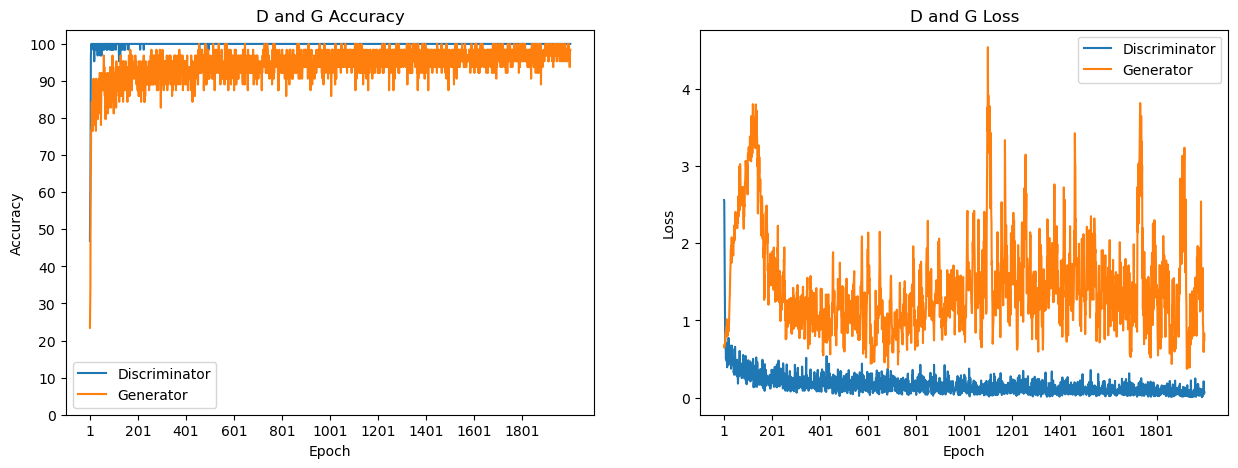

In [8]:
gan.plot_training_history()

In [9]:
gan.evaluate_discriminator(X_test,y_test)

Evaluating D [loss:  13.0593, bi-loss: 6.7611, cat-loss: 6.2982, bi-acc: 0.00%, cat-acc: 0.27%]



(13.059259414672852, 0.0)

12/12 [==============================] - 1s 41ms/step
Shape of class_probs: (364, 4)

AveP: 66.59%

Overall accuracy: 84.07%

Classification report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         9
     Class 1       0.79      0.93      0.86       132
     Class 2       0.94      0.83      0.88        92
     Class 3       0.84      0.82      0.83       131

    accuracy                           0.84       364
   macro avg       0.64      0.64      0.64       364
weighted avg       0.83      0.84      0.83       364



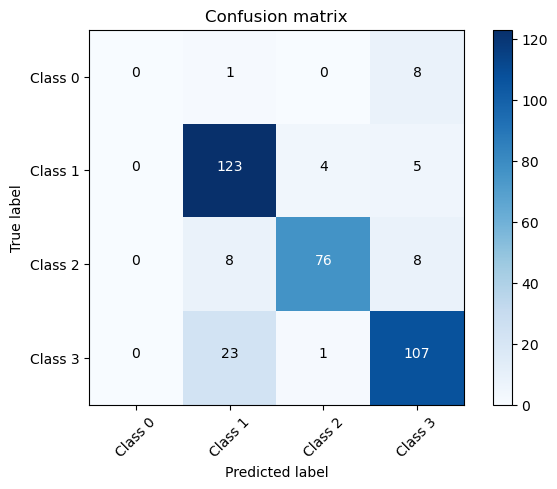

In [10]:
gan.predict(X_test,y_test)

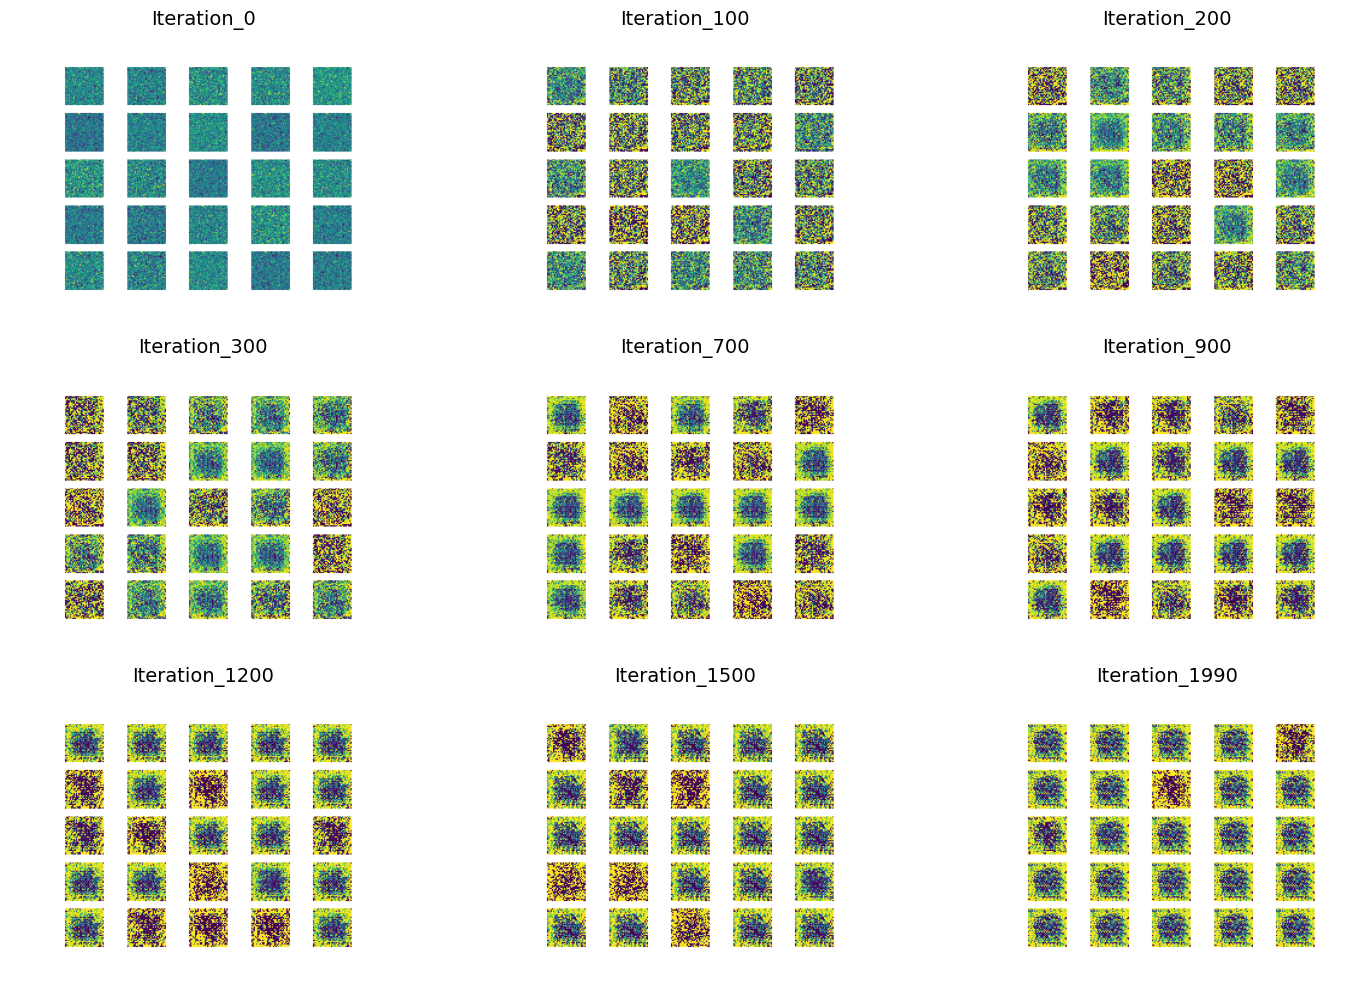

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Replace the path with your image file's path
files = [0, 100, 200, 300,700, 900,1200, 1500, 1990]

# Create a figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # Adjust the grid size as needed
axes = axes.ravel()  # Flatten the axes array for easy indexing

# Loop through the files and plot each image
for i, file in enumerate(files):
    # Read the image
    img = mpimg.imread(f'GAN_generators_output/gan_{file}.png')
    
    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f'Iteration_{file}', fontsize=14)
    axes[i].axis('off')  # Optional: hides the axes

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()
